# Telco Customer Churn – Exploratory Data Analysis

This notebook explores the Telco Customer Churn dataset. The goal is to understand which customer and service characteristics are associated with churn (Yes/No), using data cleaning, feature engineering, exploratory data analysis, and basic statistical techniques.

In [3]:
# Import libraries and set global options
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 1. Data Import and Dataset Description

We load the Telco Customer Churn CSV file into a pandas DataFrame, check basic structure, and describe the key variables such as demographics, services, billing information, and the churn flag.

In [7]:
# Load the Telco Customer Churn dataset
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)

# Basic checks
df_shape = df.shape
df_head = df.head()
df_shape, df_head

((7043, 21),
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
 0  7590-VHVEG  Female              0     Yes         No       1           No   
 1  5575-GNVDE    Male              0      No         No      34          Yes   
 2  3668-QPYBK    Male              0      No         No       2          Yes   
 3  7795-CFOCW    Male              0      No         No      45           No   
 4  9237-HQITU  Female              0      No         No       2          Yes   
 
       MultipleLines InternetService OnlineSecurity OnlineBackup  \
 0  No phone service             DSL             No          Yes   
 1                No             DSL            Yes           No   
 2                No             DSL            Yes          Yes   
 3  No phone service             DSL            Yes           No   
 4                No     Fiber optic             No           No   
 
   DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
 0        

## 2. Deep Initial Profiling

We inspect data types, missing values, and basic statistics for numeric and categorical features. A custom summary function is used to provide a compact overview.

In [8]:
# Basic structural information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
# Numeric summary
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
# Simple frequency table for selected categorical features
categorical_cols = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "InternetService", "Contract",
    "PaperlessBilling", "PaymentMethod", "Churn"
],

for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts(dropna=False))


Value counts for ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'InternetService', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']:
gender  SeniorCitizen  Partner  Dependents  PhoneService  InternetService  Contract        PaperlessBilling  PaymentMethod              Churn
Male    0              No       No          Yes           Fiber optic      Month-to-month  Yes               Electronic check           Yes      140
Female  0              No       No          Yes           Fiber optic      Month-to-month  Yes               Electronic check           Yes      131
        1              No       No          Yes           Fiber optic      Month-to-month  Yes               Electronic check           Yes       83
        0              No       No          Yes           Fiber optic      Month-to-month  Yes               Electronic check           No        71
Male    0              No       No          Yes           Fiber optic      Month-to-month  Yes   

In [11]:
# Custom summary function (UDF) for detailed overview
def detailed_summary(data: pd.DataFrame) -> pd.DataFrame:
    summary = pd.DataFrame({
        "DataType": data.dtypes,
        "MissingValues": data.isna().sum(),
        "UniqueValues": data.nunique(),
        "Mean": data.select_dtypes(include=["number"]).mean(),
        "Median": data.select_dtypes(include=["number"]).median(),
        "StdDev": data.select_dtypes(include=["number"]).std(),
    })
    return summary

detailed_summary(df)

,DataType,MissingValues,UniqueValues,Mean,Median,StdDev
Churn,object,0,2,NaN,NaN,NaN
Contract,object,0,3,NaN,NaN,NaN
Dependents,object,0,2,NaN,NaN,NaN
DeviceProtection,object,0,3,NaN,NaN,NaN
InternetService,object,0,3,NaN,NaN,NaN
MonthlyCharges,float64,0,1585,64.761692,70.35,30.090047
MultipleLines,object,0,3,NaN,NaN,NaN
OnlineBackup,object,0,3,NaN,NaN,NaN
OnlineSecurity,object,0,3,NaN,NaN,NaN
PaperlessBilling,object,0,2,NaN,NaN,NaN


## 3. Advanced Data Cleaning (Telco-Specific)

We handle missing or invalid values (especially in `TotalCharges`), check duplicates, and ensure appropriate data types. A list comprehension is used to collect service-related columns.

In [12]:
# Convert TotalCharges to numeric and inspect problematic rows
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
missing_total = df[df["TotalCharges"].isna()]
missing_total.head(), missing_total.shape

(      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
 488   4472-LVYGI  Female              0     Yes        Yes       0   
 753   3115-CZMZD    Male              0      No        Yes       0   
 936   5709-LVOEQ  Female              0     Yes        Yes       0   
 1082  4367-NUYAO    Male              0     Yes        Yes       0   
 1340  1371-DWPAZ  Female              0     Yes        Yes       0   
 
      PhoneService     MultipleLines InternetService       OnlineSecurity  \
 488            No  No phone service             DSL                  Yes   
 753           Yes                No              No  No internet service   
 936           Yes                No             DSL                  Yes   
 1082          Yes               Yes              No  No internet service   
 1340           No  No phone service             DSL                  Yes   
 
              OnlineBackup     DeviceProtection          TechSupport  \
 488                    No          

In [13]:
# Handle missing TotalCharges by dropping those few rows (alternative: impute)
df = df.dropna(subset=["TotalCharges"]).copy()
df.shape

(7032, 21)

In [14]:
# List comprehension example: collect all service-related columns
service_cols = [col for col in df.columns if col in [
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]]
service_cols

['PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies']

In [15]:
# Check for duplicate customer IDs
duplicate_ids = df["customerID"].duplicated().sum()
duplicate_ids

np.int64(0)

In [16]:
# Ensure correct dtypes
df["SeniorCitizen"] = df["SeniorCitizen"].astype(int)
categorical_features = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod", "Churn"
]
for col in categorical_features:
    df[col] = df[col].astype("category")

numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
df[numeric_features].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [17]:
# IQR-based outlier detector (UDF)
def detect_outliers_iqr(data: pd.Series) -> pd.Series:
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (data < lower) | (data > upper)

outliers_monthly = detect_outliers_iqr(df["MonthlyCharges"]).sum()
outliers_total = detect_outliers_iqr(df["TotalCharges"]).sum()
outliers_monthly, outliers_total

(np.int64(0), np.int64(0))

## 4. Feature Engineering (Lambda, UDF, and New Features)

We create new features that may help explain churn, including numeric flags and grouped categories. This section explicitly demonstrates lambda functions and user-defined functions.

In [18]:
# Lambda example: create numeric churn flag
df["ChurnFlag"] = df["Churn"].apply(lambda x: 1 if x == "Yes" else 0)

# Tenure group using a helper function
def tenure_to_group(tenure: int) -> str:
    if tenure <= 12:
        return "New"
    elif tenure <= 24:
        return "Recent"
    elif tenure <= 48:
        return "Established"
    else:
        return "Loyal"

df["TenureGroup"] = df["tenure"].apply(tenure_to_group)
df["TenureGroup"] = df["TenureGroup"].astype("category")
df["ChurnFlag"].value_counts(), df["TenureGroup"].value_counts()

(ChurnFlag
 0    5163
 1    1869
 Name: count, dtype: int64,
 TenureGroup
 Loyal          2239
 New            2175
 Established    1594
 Recent         1024
 Name: count, dtype: int64)

In [19]:
# UDF example: count number of subscribed services per customer
def count_services(row: pd.Series) -> int:
    count = 0
    for col in service_cols:
        if row[col] == "Yes":
            count += 1
    return count

df["ServiceCount"] = df.apply(count_services, axis=1)

# Additional feature: family flag (has partner or dependents)
df["FamilyFlag"] = np.where((df["Partner"] == "Yes") | (df["Dependents"] == "Yes"), 1, 0)
df[["ServiceCount", "FamilyFlag"]].describe()

,ServiceCount,FamilyFlag
count,7032.000000,7032.000000
mean,3.363339,0.533561
std,2.062067,0.498908
min,0.000000,0.000000
25%,1.000000,0.000000
50%,3.000000,1.000000
75%,5.000000,1.000000
max,8.000000,1.000000


## 5. Descriptive Statistics

We summarize key numeric and categorical variables to understand typical customer tenure, charges, and churn distribution.

In [20]:
# Numeric descriptive statistics
df[["tenure", "MonthlyCharges", "TotalCharges", "ServiceCount"]].describe()

,tenure,MonthlyCharges,TotalCharges,ServiceCount
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441,3.363339
std,24.545260,30.085974,2266.771362,2.062067
min,1.000000,18.250000,18.800000,0.000000
25%,9.000000,35.587500,401.450000,1.000000
50%,29.000000,70.350000,1397.475000,3.000000
75%,55.000000,89.862500,3794.737500,5.000000
max,72.000000,118.750000,8684.800000,8.000000


In [21]:
# Categorical descriptive statistics for selected features
cat_summary_cols = ["Churn", "Contract", "InternetService", "PaymentMethod", "TenureGroup"]

for col in cat_summary_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(normalize=True).round(3))


=== Churn ===
Churn
No     0.734
Yes    0.266
Name: proportion, dtype: float64

=== Contract ===
Contract
Month-to-month    0.551
Two year          0.240
One year          0.209
Name: proportion, dtype: float64

=== InternetService ===
InternetService
Fiber optic    0.440
DSL            0.344
No             0.216
Name: proportion, dtype: float64

=== PaymentMethod ===
PaymentMethod
Electronic check             0.336
Mailed check                 0.228
Bank transfer (automatic)    0.219
Credit card (automatic)      0.216
Name: proportion, dtype: float64

=== TenureGroup ===
TenureGroup
Loyal          0.318
New            0.309
Established    0.227
Recent         0.146
Name: proportion, dtype: float64


## 6. Univariate Visualizations – Distributions

We visualize the distributions of tenure, monthly charges, total charges, and churn-related categorical features.

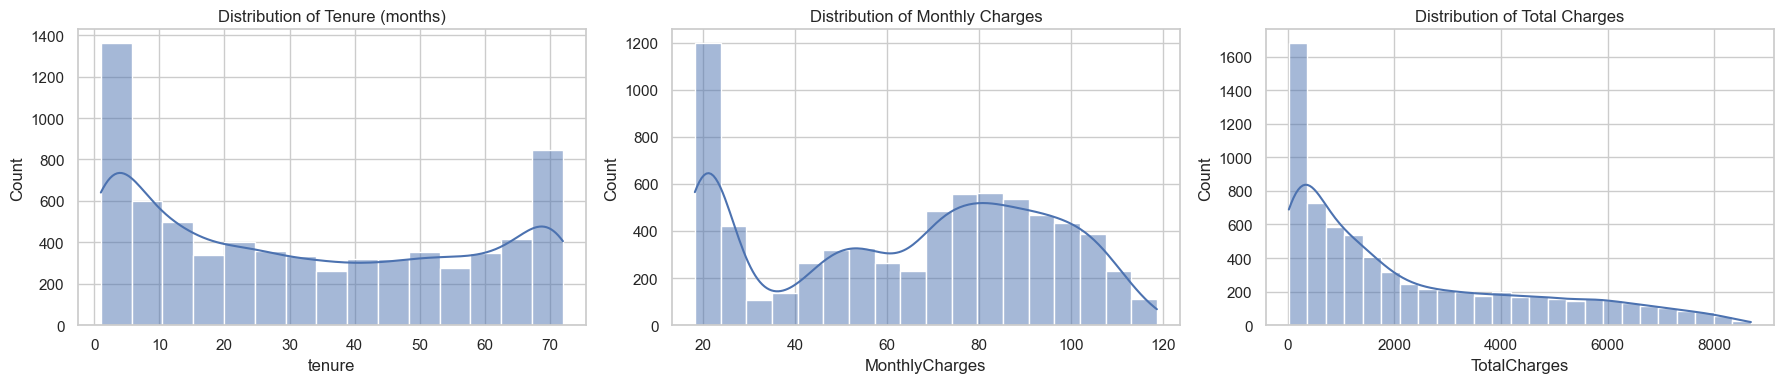

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(df["tenure"], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Tenure (months)")

sns.histplot(df["MonthlyCharges"], kde=True, ax=axes[1])
axes[1].set_title("Distribution of Monthly Charges")

sns.histplot(df["TotalCharges"], kde=True, ax=axes[2])
axes[2].set_title("Distribution of Total Charges")

plt.tight_layout()
plt.show()

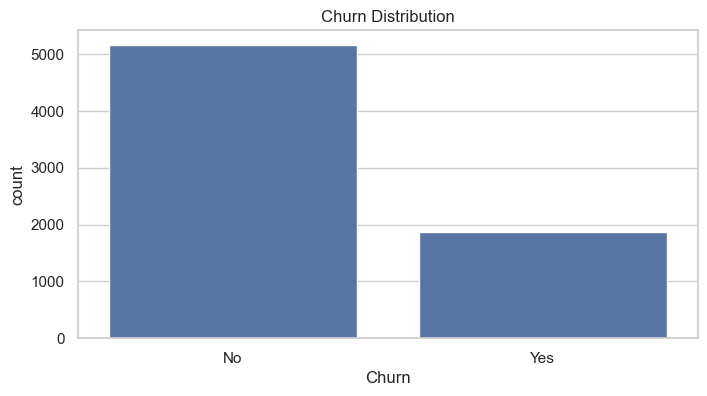

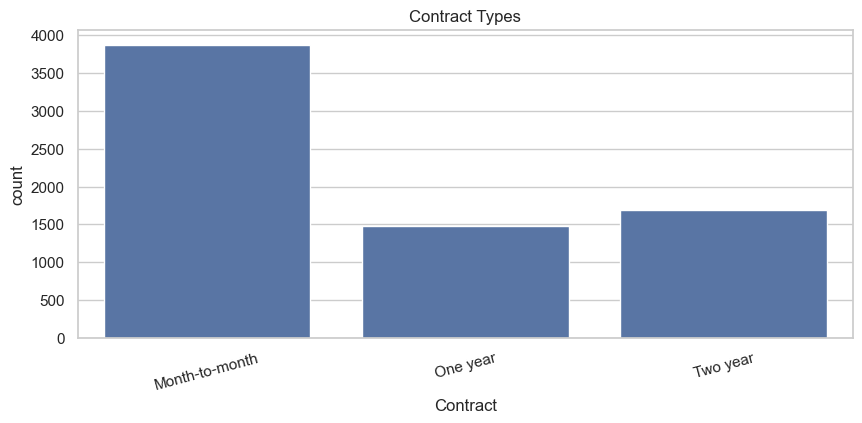

In [23]:
plt.figure(figsize=(8, 4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

plt.figure(figsize=(10, 4))
sns.countplot(x="Contract", data=df, order=["Month-to-month", "One year", "Two year"])
plt.title("Contract Types")
plt.xticks(rotation=15)
plt.show()

## 7. Bivariate Analysis – Churn vs Key Features

We compare churn across different customer segments and examine how numeric variables differ between churned and non-churned customers.

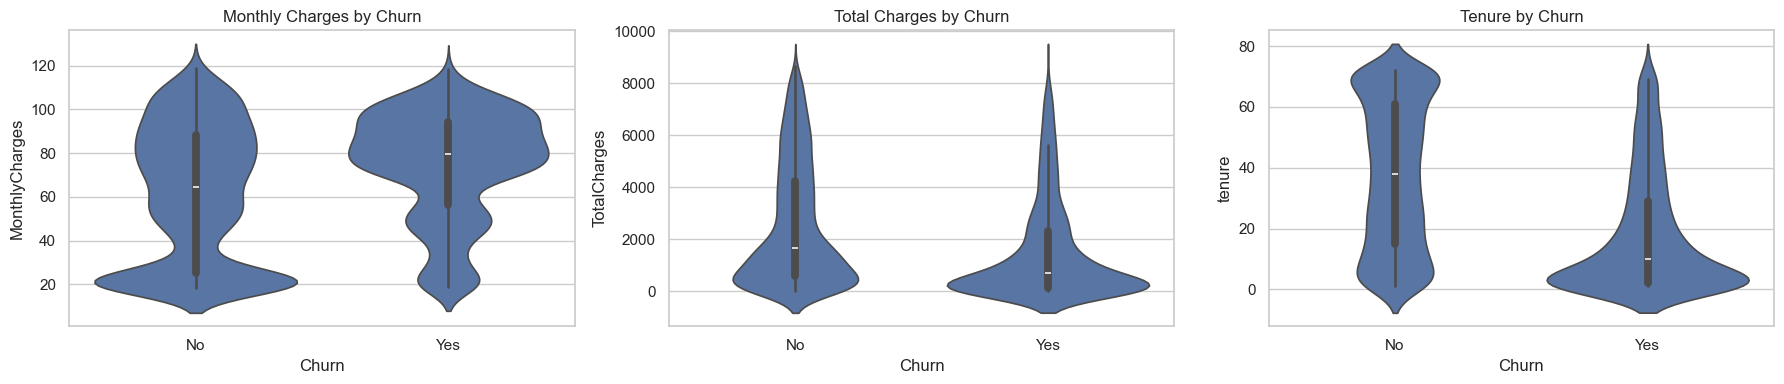

In [24]:
# Numeric variables vs churn (violin plots)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.violinplot(x="Churn", y="MonthlyCharges", data=df, ax=axes[0])
axes[0].set_title("Monthly Charges by Churn")

sns.violinplot(x="Churn", y="TotalCharges", data=df, ax=axes[1])
axes[1].set_title("Total Charges by Churn")

sns.violinplot(x="Churn", y="tenure", data=df, ax=axes[2])
axes[2].set_title("Tenure by Churn")

plt.tight_layout()
plt.show()

In [25]:
# Categorical features vs churn (proportions)
def churn_rate_by_category(column: str) -> pd.DataFrame:
    ct = pd.crosstab(df[column], df["Churn"], normalize="index")
    return ct

churn_by_contract = churn_rate_by_category("Contract")
churn_by_tenure_group = churn_rate_by_category("TenureGroup")
churn_by_contract, churn_by_tenure_group

(Churn                 No       Yes
 Contract                          
 Month-to-month  0.572903  0.427097
 One year        0.887228  0.112772
 Two year        0.971513  0.028487,
 Churn              No       Yes
 TenureGroup                    
 Established  0.796110  0.203890
 Loyal        0.904868  0.095132
 New          0.523218  0.476782
 Recent       0.712891  0.287109)

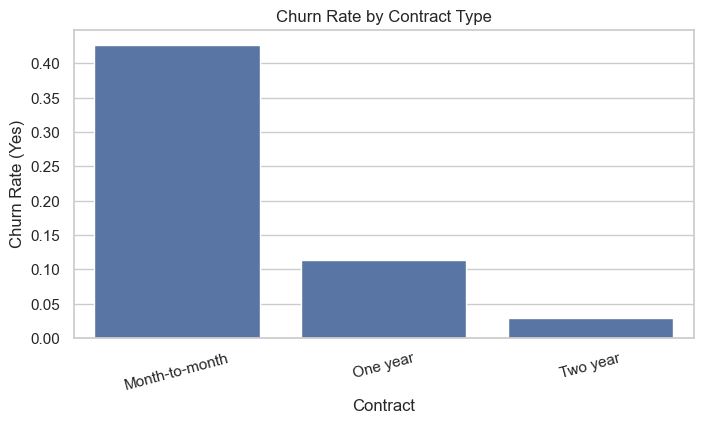

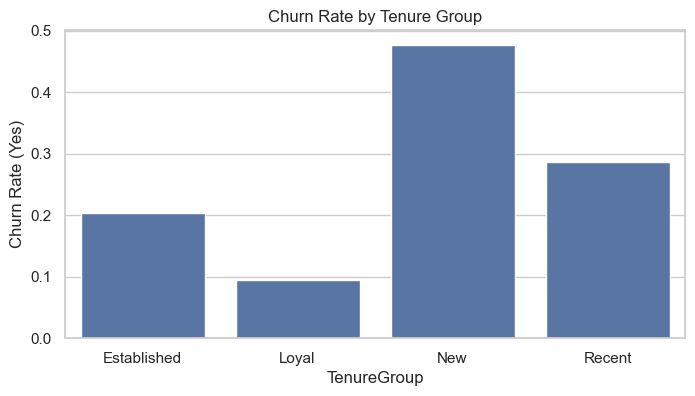

In [26]:
plt.figure(figsize=(8, 4))
sns.barplot(x=churn_by_contract.index, y=churn_by_contract["Yes"].values)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate (Yes)")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(x=churn_by_tenure_group.index, y=churn_by_tenure_group["Yes"].values)
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Churn Rate (Yes)")
plt.show()

## 8. Correlation and Multivariate Patterns

We compute correlations among numeric features, including the churn flag, and visualize them using a heatmap to identify important relationships.

In [27]:
numeric_for_corr = df[["tenure", "MonthlyCharges", "TotalCharges", "ServiceCount", "FamilyFlag", "ChurnFlag"]]
corr_matrix = numeric_for_corr.corr()
corr_matrix

,tenure,MonthlyCharges,TotalCharges,ServiceCount,FamilyFlag,ChurnFlag
tenure,1.000000,0.246862,0.825880,0.524441,0.347367,-0.354049
MonthlyCharges,0.246862,1.000000,0.651065,0.802368,0.056393,0.192858
TotalCharges,0.825880,0.651065,1.000000,0.796885,0.277450,-0.199484
ServiceCount,0.524441,0.802368,0.796885,1.000000,0.186601,-0.067459
FamilyFlag,0.347367,0.056393,0.277450,0.186601,1.000000,-0.162113
ChurnFlag,-0.354049,0.192858,-0.199484,-0.067459,-0.162113,1.000000


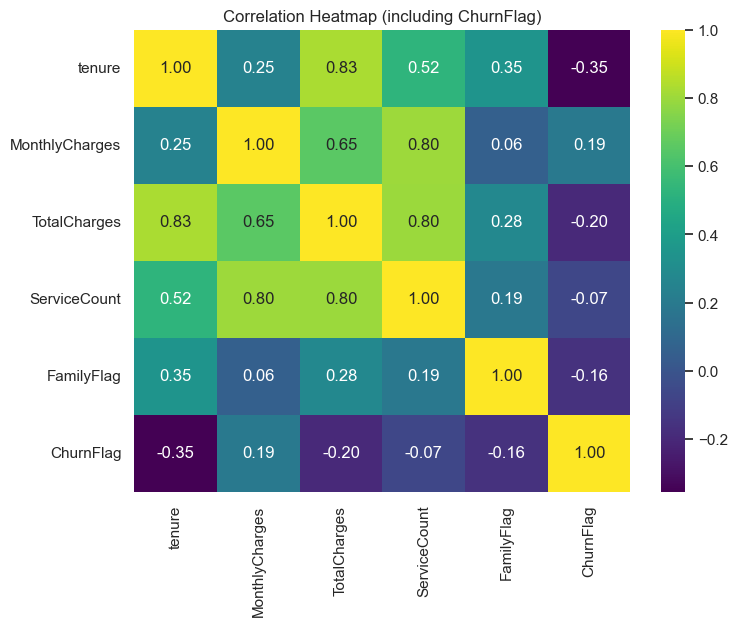

In [28]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation Heatmap (including ChurnFlag)")
plt.show()

## 9. Group Analysis / Segmentation

We aggregate churn rate, tenure, and charges across key customer segments such as contract type, internet service, tenure group, and service count.

In [32]:
df["ChurnFlag"] = pd.to_numeric(df["ChurnFlag"], errors="coerce")
df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors="coerce")
df["tenure"] = pd.to_numeric(df["tenure"], errors="coerce")

group_contract = df.groupby("Contract").agg({
    "ChurnFlag": "mean",
    "MonthlyCharges": "mean",
    "tenure": "mean"
}).rename(columns={"ChurnFlag": "ChurnRate"})

group_contract

C:\Users\Akshay Utture\AppData\Local\Temp\ipykernel_8020\3294294229.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_contract = df.groupby("Contract").agg({


,ChurnRate,MonthlyCharges,tenure
Contract,,,
Month-to-month,0.427097,66.398490,18.036645
One year,0.112772,65.079416,42.073370
Two year,0.028487,60.872374,57.071810


In [33]:
# Multi-level groupby: InternetService and Contract
group_internet_contract = df.groupby(["InternetService", "Contract"]).agg({
    "ChurnFlag": "mean",
    "MonthlyCharges": "mean"
}).rename(columns={"ChurnFlag": "ChurnRate"})
group_internet_contract

C:\Users\Akshay Utture\AppData\Local\Temp\ipykernel_8020\3944440078.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_internet_contract = df.groupby(["InternetService", "Contract"]).agg({


ChurnRate  MonthlyCharges
InternetService Contract                                 
DSL             Month-to-month   0.322159       50.219501
                One year         0.092982       61.396754
                Two year         0.019262       70.507303
Fiber optic     Month-to-month   0.546053       87.021194
                One year         0.192950       98.779499
                Two year         0.072261      104.571445
No              Month-to-month   0.188931       20.409542
                One year         0.024793       20.822590
                Two year         0.007899       21.773697

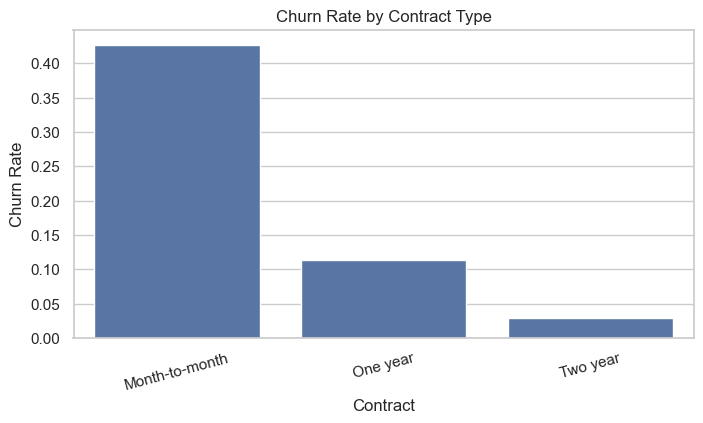

In [34]:
plt.figure(figsize=(8, 4))
sns.barplot(x=group_contract.index, y=group_contract["ChurnRate"].values)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xticks(rotation=15)
plt.show()

## 10. Feature Analysis and Simple Statistical Tests

We test whether churned and non-churned customers differ in key numeric variables and examine associations between churn and important categorical features.

In [35]:
# T-test: MonthlyCharges for churned vs non-churned customers
monthly_churn_yes = df.loc[df["Churn"] == "Yes", "MonthlyCharges"]
monthly_churn_no = df.loc[df["Churn"] == "No", "MonthlyCharges"]

ttest_monthly = stats.ttest_ind(monthly_churn_yes, monthly_churn_no, equal_var=False)
ttest_monthly

TtestResult(statistic=np.float64(18.34091879095257), pvalue=np.float64(2.6573571445160277e-72), df=np.float64(4139.667421874439))

In [36]:
# Chi-square test: association between Churn and Contract type
contingency_contract = pd.crosstab(df["Churn"], df["Contract"])
chi2_contract = stats.chi2_contingency(contingency_contract)
chi2_contract[0], chi2_contract[1]  # chi-square statistic and p-value

(np.float64(1179.5458287339447), np.float64(7.326182186264635e-257))

## 11. Optional: PCA for Numeric Features

We apply Principal Component Analysis (PCA) to a subset of standardized numeric variables to explore underlying structure. This is optional but provides additional insight into patterns in the data.

In [37]:
numeric_for_pca = df[["tenure", "MonthlyCharges", "TotalCharges", "ServiceCount"]]
scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(numeric_for_pca)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(numeric_scaled)
pca.explained_variance_ratio_

array([0.73797237, 0.20938428])

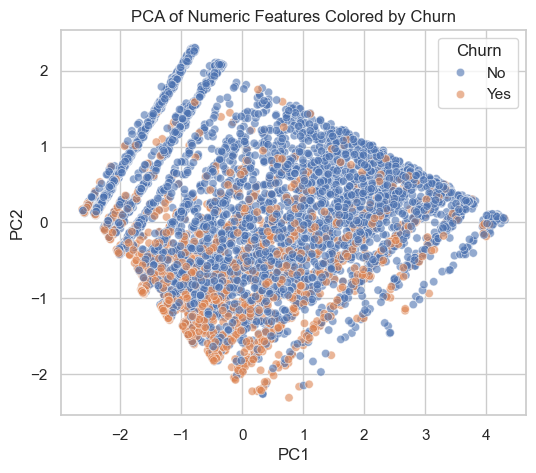

In [38]:
pca_df = pd.DataFrame(principal_components, columns=["PC1", "PC2"])
pca_df["Churn"] = df["Churn"].values

plt.figure(figsize=(6, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Churn", alpha=0.6)
plt.title("PCA of Numeric Features Colored by Churn")
plt.show()

## 12. Insights and Conclusions

Use this section to summarize the key findings from the analysis:

- Overall churn rate and how it varies by contract type, tenure group, internet service, and payment method.
- Differences in tenure, monthly charges, and total charges between churned and non-churned customers.
- Important features correlated with churn (for example, contract type, tenure, service count, billing method).
- Any notable clusters or patterns suggested by PCA or group analysis.

Also discuss limitations (for example, observational nature of the data, missing variables) and propose next steps such as building a predictive churn model or testing retention strategies.